In [1]:
import ast
import torch
import pandas as pd

reference_data = torch.load("/data1/xw3763/project/gflow/ChemGFN/data/24_points/buffer_24_non_zero.pt")

In [2]:
reference_data = reference_data.tolist()

In [3]:
methods_to_path_dict = {
    "TB": "/data1/xw3763/project/gflow/ChemGFN/logs/eval/Expr24_CFG_TB_no_data_buffer/eval/runs/2026-01-07_11-10-47/test_samples/samples_test_0.csv",
    "RapTB_kmin_0": "/data1/xw3763/project/gflow/ChemGFN/logs/eval/Expr24_CFG_RapTB_kmin_0_no_data_buffer/eval/runs/2026-01-07_10-57-22/test_samples/samples_test_0.csv",
    "RapTB_kmin_2": "/data1/xw3763/project/gflow/ChemGFN/logs/eval/Expr24_CFG_RapTB_kmin_2_no_data_buffer/eval/runs/2026-01-07_11-23-49/test_samples/samples_test_0.csv",
    
}


In [4]:
test_tokens_dict = {}

for method, path in methods_to_path_dict.items():
    test_samples = pd.read_csv(path)
    test_tokens_dict[method] = [ast.literal_eval(token) for token in test_samples["token_ids"].tolist()]

In [5]:
from collections import Counter
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# 覆盖率计算
def compute_coverage(ref_seqs: List[List], sampled_seqs: List[List]) -> Tuple[int, int, float]:
    ref_set = {tuple(s) for s in ref_seqs}
    sampled_set = {tuple(s) for s in sampled_seqs}
    covered = sum(1 for s in ref_set if s in sampled_set)
    return covered, len(ref_set), covered / max(len(ref_set), 1)

# 多方法覆盖率表
def compute_coverage_table(ref_seqs: List[List], sampled_dict: Dict[str, List[List]]) -> pd.DataFrame:
    rows = []
    for name, seqs in sampled_dict.items():
        covered, total, cov = compute_coverage(ref_seqs, seqs)
        rows.append({"method": name, "covered": covered, "total_ref_unique": total, "coverage": cov})
    return pd.DataFrame(rows).sort_values("coverage", ascending=False).reset_index(drop=True)

# 按位置分布
def position_distributions(seqs: List[List]):
    max_len = max((len(s) for s in seqs), default=0)
    pos_counters = []
    for i in range(max_len):
        c = Counter(s[i] for s in seqs if len(s) > i)
        pos_counters.append(c)
    return pos_counters

# 计算 KL、JS、L1 等分布差异
def _kl_div(p: np.ndarray, q: np.ndarray, eps: float = 1e-9) -> float:
    p_safe, q_safe = p + eps, q + eps
    return float(np.sum(p_safe * np.log(p_safe / q_safe)))


def _js_div(p: np.ndarray, q: np.ndarray, eps: float = 1e-9) -> float:
    m = 0.5 * (p + q)
    return 0.5 * _kl_div(p, m, eps) + 0.5 * _kl_div(q, m, eps)


def compute_position_divergence(ref_pos, sampled_pos_dict: Dict[str, List[Counter]], eps: float = 1e-9) -> pd.DataFrame:
    rows = []
    if not sampled_pos_dict:
        return pd.DataFrame()
    n_pos = max(len(ref_pos), max(len(v) for v in sampled_pos_dict.values()))
    for method, pos_list in sampled_pos_dict.items():
        for i in range(n_pos):
            ref_c = ref_pos[i] if i < len(ref_pos) else Counter()
            samp_c = pos_list[i] if i < len(pos_list) else Counter()
            tokens = sorted(set(ref_c.keys()) | set(samp_c.keys()), key=str)
            if not tokens:
                continue
            ref_total = sum(ref_c.values()) or 1
            samp_total = sum(samp_c.values()) or 1
            ref_probs = np.array([ref_c[t] / ref_total for t in tokens], dtype=float)
            samp_probs = np.array([samp_c[t] / samp_total for t in tokens], dtype=float)
            kl_sr = _kl_div(samp_probs, ref_probs, eps)  # KL(sample||ref)
            kl_rs = _kl_div(ref_probs, samp_probs, eps)  # KL(ref||sample)
            js = _js_div(samp_probs, ref_probs, eps)
            l1 = float(np.sum(np.abs(samp_probs - ref_probs)))
            rows.append({
                "method": method,
                "position": i,
                "kl_sample_to_ref": kl_sr,
                "kl_ref_to_sample": kl_rs,
                "js": js,
                "l1": l1,
            })
    return pd.DataFrame(rows)

# 指标折线图：横轴 position，纵轴指标值
def plot_metric_lines(pos_div_df: pd.DataFrame, metrics, method_order=None, out_dir="figs_pos_multi", show=True):
    if pos_div_df.empty:
        return
    os.makedirs(out_dir, exist_ok=True)
    if method_order is None:
        method_order = sorted(pos_div_df["method"].unique())
    for metric in metrics:
        plt.figure(figsize=(8, 4))
        for m in method_order:
            sub = pos_div_df[pos_div_df["method"] == m].sort_values("position")
            plt.plot(sub["position"], sub[metric], marker="o", label=m)
        plt.xlabel("position")
        plt.ylabel(metric)
        plt.title(f"{metric} per position")
        plt.legend()
        plt.tight_layout()
        save_path = os.path.join(out_dir, f"line_{metric}.png")
        plt.savefig(save_path)
        if show:
            plt.show()
        plt.close()

# 多方法 + ref 的分布对比图（改为显示与 ref 的概率差值）
def plot_pos_dists_multi(ref_pos, sampled_pos_dict: Dict[str, List[Counter]], out_dir="figs_pos_multi", show=True):
    os.makedirs(out_dir, exist_ok=True)
    if not sampled_pos_dict:
        return
    n_pos = max(len(ref_pos), max(len(v) for v in sampled_pos_dict.values()))
    method_names = list(sampled_pos_dict.keys())
    for i in range(n_pos):
        ref_c = ref_pos[i] if i < len(ref_pos) else Counter()
        tokens = set(ref_c.keys())
        for pos_list in sampled_pos_dict.values():
            tokens |= set(pos_list[i].keys()) if i < len(pos_list) else set()
        if not tokens:
            continue
        tokens = sorted(tokens, key=str)

        ref_total = sum(ref_c.values()) or 1
        ref_probs = np.array([ref_c[t] / ref_total for t in tokens], dtype=float)

        width = 0.8 / max(len(method_names), 1)
        x = list(range(len(tokens)))
        base = [p - width * (len(method_names) - 1) / 2 for p in x]

        plt.figure(figsize=(max(6, len(tokens) * 0.6), 4))
        plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)

        for idx, name in enumerate(method_names):
            pos_list = sampled_pos_dict[name]
            samp_c = pos_list[i] if i < len(pos_list) else Counter()
            samp_total = sum(samp_c.values()) or 1
            samp_probs = np.array([samp_c[t] / samp_total for t in tokens], dtype=float)
            deltas = samp_probs - ref_probs  # 正负差值
            offsets = [p + width * idx for p in base]
            plt.bar(offsets, deltas, width=width, label=name)

        plt.xticks(x, tokens, rotation=45, ha="right")
        plt.ylabel("probability delta (sample - ref)")
        plt.title(f"Position {i} probability delta vs ref")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"pos_{i}.png"))
        if show:
            plt.show()
        plt.close()

,method,covered,total_ref_unique,coverage
0,TB,10,2520,0.40%
1,RapTB_kmin_2,4,2520,0.16%
2,RapTB_kmin_0,3,2520,0.12%


,method,position,kl_sample_to_ref,kl_ref_to_sample,js,l1
0,TB,0,1.640759,14.603548,0.426890,1.606349
1,TB,1,0.246614,2.602878,0.074124,0.547857
2,TB,2,1.213302,9.962717,0.327135,1.366617
3,TB,3,0.434993,4.124831,0.125476,0.789385
4,TB,4,0.680551,7.240105,0.200929,0.973274


,kl_sample_to_ref,kl_ref_to_sample,js,l1
method,,,,
TB,0.7828,7.2318,0.2167,0.9911
RapTB_kmin_2,0.8543,8.8326,0.2402,1.0303
RapTB_kmin_0,1.0143,8.6479,0.2641,1.1314


method,TB,RapTB_kmin_2,RapTB_kmin_0
position,,,
0,1.6408,1.2745,1.6236
1,0.2466,0.1774,0.3350
2,1.2133,1.4514,1.5080
3,0.4350,0.3477,0.2912
4,0.6806,1.1704,1.6052
5,0.2989,0.3449,0.4026
6,0.9649,1.2137,1.3342


method,TB,RapTB_kmin_2,RapTB_kmin_0
position,,,
0,14.6035,12.9342,13.4712
1,2.6029,2.5421,2.6886
2,9.9627,13.7828,11.9929
3,4.1248,4.0480,4.0037
4,7.2401,12.3111,12.5488
5,4.5299,4.5655,4.6144
6,7.5588,11.6446,11.2156


method,TB,RapTB_kmin_2,RapTB_kmin_0
position,,,
0,0.4269,0.3548,0.4247
1,0.0741,0.0581,0.0954
2,0.3271,0.3920,0.3776
3,0.1255,0.1055,0.0933
4,0.2009,0.3321,0.3886
5,0.0985,0.1085,0.1216
6,0.2639,0.3305,0.3473


method,TB,RapTB_kmin_2,RapTB_kmin_0
position,,,
0,1.6063,1.4278,1.6057
1,0.5479,0.3550,0.7160
2,1.3666,1.5254,1.4838
3,0.7894,0.6256,0.5156
4,0.9733,1.3651,1.4655
5,0.5079,0.5701,0.7160
6,1.1461,1.3433,1.4171


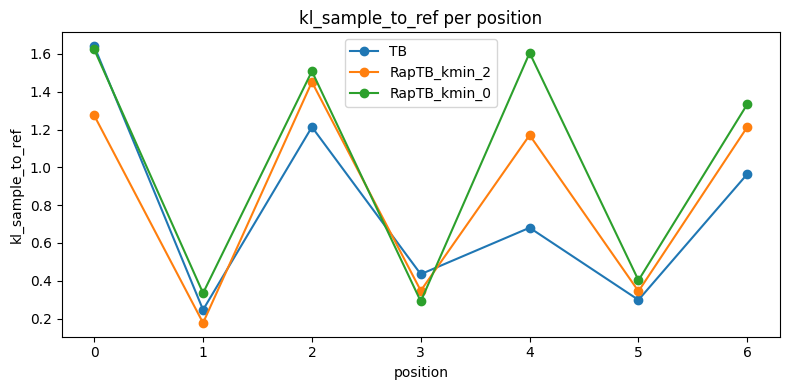

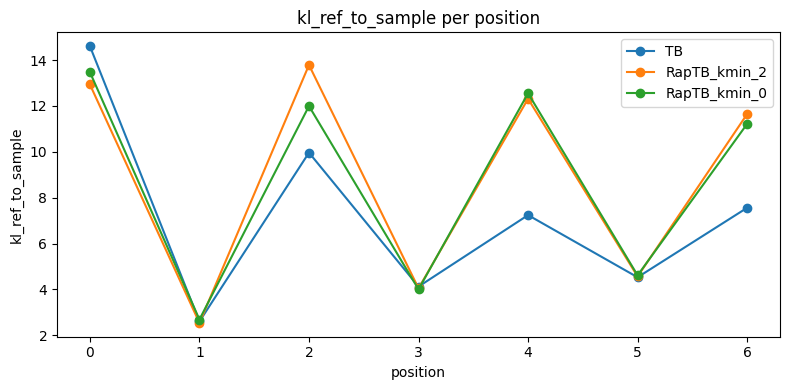

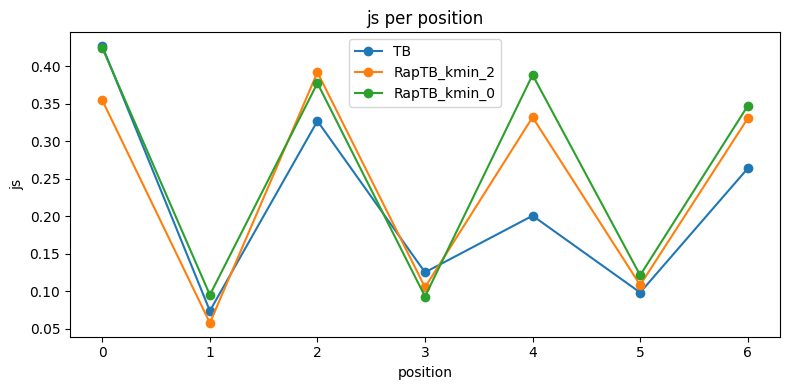

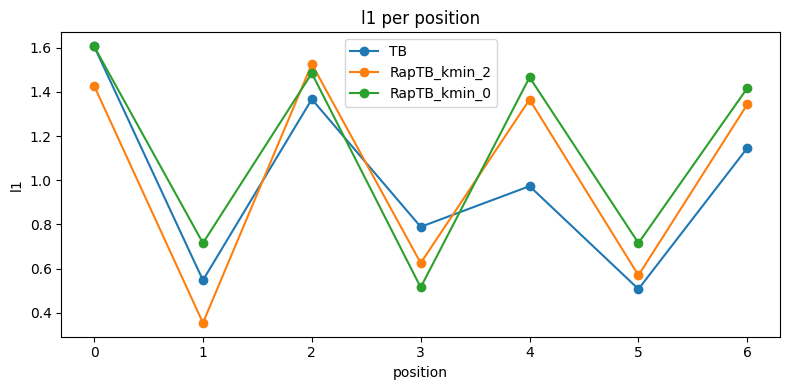

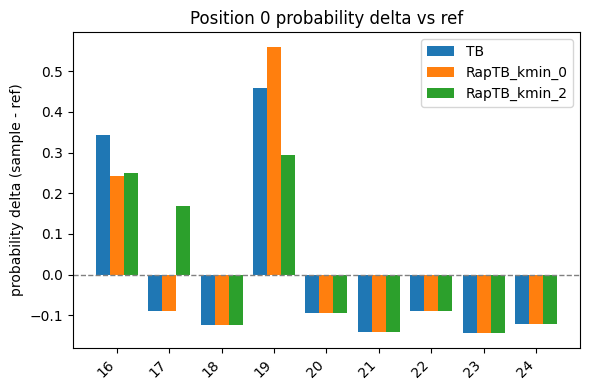

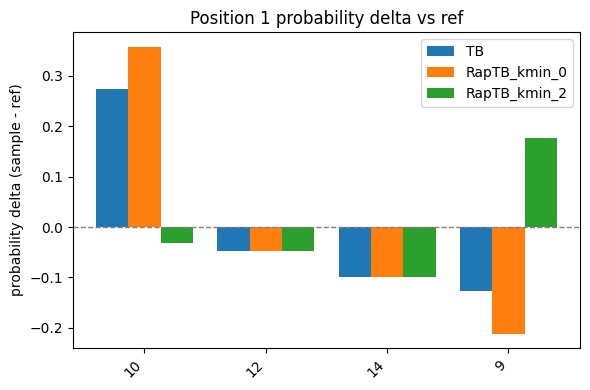

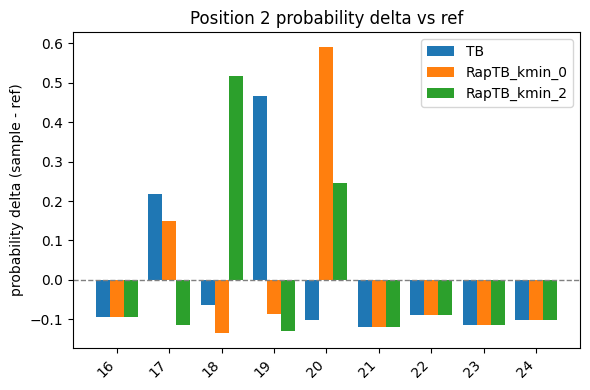

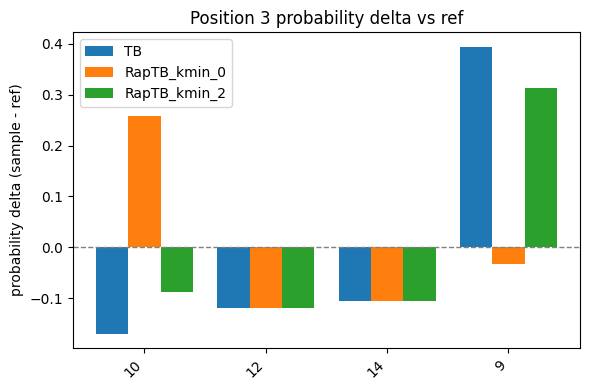

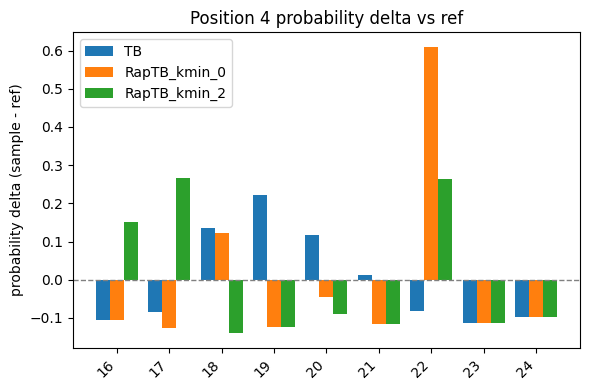

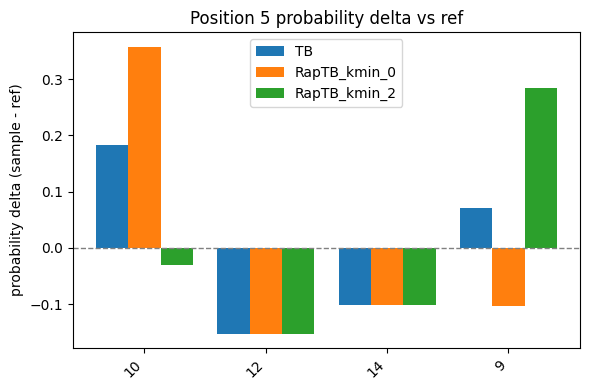

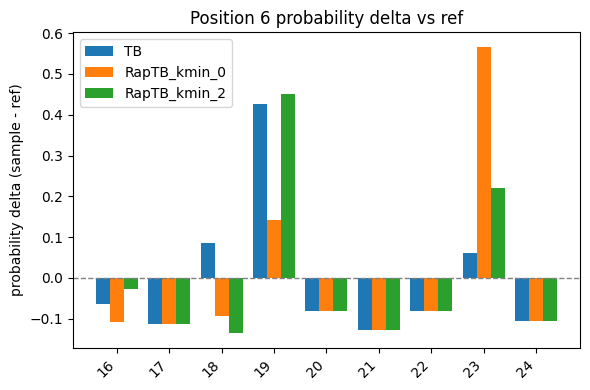

per-position plots saved to figs_pos_multi/


In [6]:
from IPython.display import display
coverage_df = compute_coverage_table(reference_data, test_tokens_dict)
display(coverage_df.style.format({"coverage": "{:.2%}"}))

ref_pos = position_distributions(reference_data)
sample_pos_dict = {name: position_distributions(seqs) for name, seqs in test_tokens_dict.items()}

# 计算按位置的 KL/JS/L1，并显示平均指标 + 每位置表
pos_div_df = compute_position_divergence(ref_pos, sample_pos_dict, eps=1e-9)
display(pos_div_df.head())
summary_div = (
    pos_div_df.groupby("method")[
        ["kl_sample_to_ref", "kl_ref_to_sample", "js", "l1"]
    ]
    .mean()
    .sort_values("js")
)
display(summary_div.style.format("{:.4f}"))

method_order = coverage_df["method"].tolist()
metrics = ["kl_sample_to_ref", "kl_ref_to_sample", "js", "l1"]
for metric in metrics:
    pivot = pos_div_df.pivot(index="position", columns="method", values=metric)
    pivot = pivot.reindex(columns=method_order)
    display(pivot.style.format("{:.4f}").set_caption(f"{metric} per position"))

plot_metric_lines(pos_div_df, metrics=metrics, method_order=method_order, out_dir="figs_pos_multi", show=True)
plot_pos_dists_multi(ref_pos, sample_pos_dict, out_dir="figs_pos_multi", show=True)
print("per-position plots saved to figs_pos_multi/")